## Cell 1 — Library Import

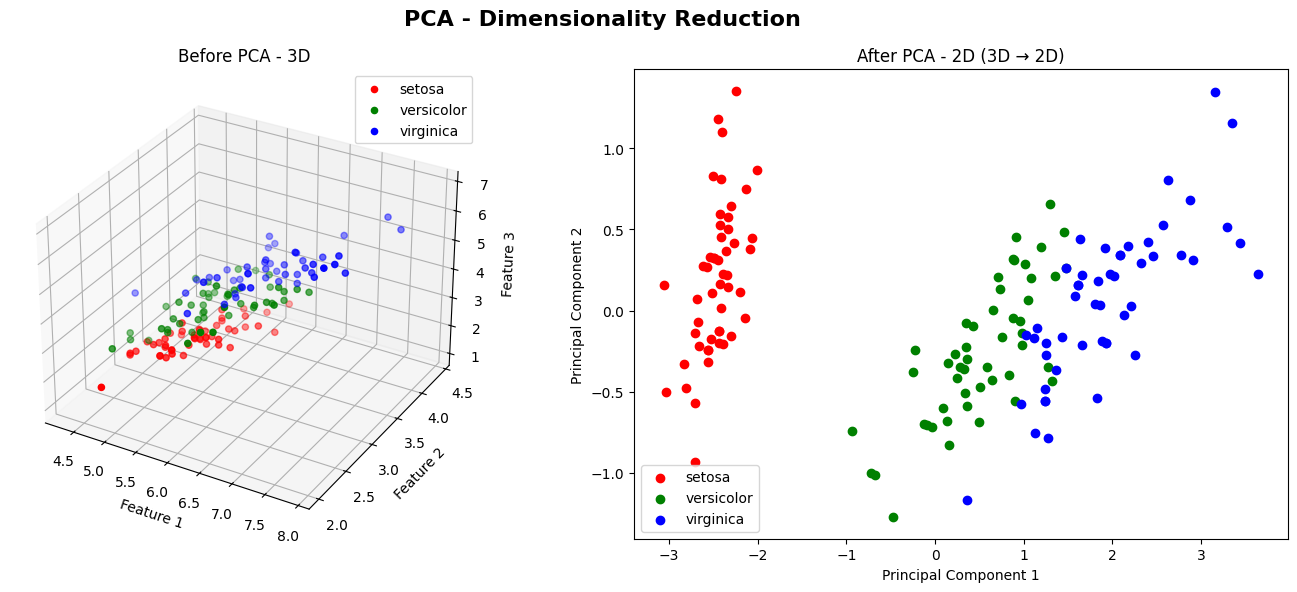

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D

data = load_iris()
X = data.data
y = data.target
labels = data.target_names
colors = ['red', 'green', 'blue']

fig = plt.figure(figsize=(14, 6))

# ── Before PCA - 3D plot (3টা feature) ──
ax1 = fig.add_subplot(121, projection='3d')
for i, color in enumerate(colors):
    ax1.scatter(X[y==i, 0], X[y==i, 1], X[y==i, 2],
                color=color, label=labels[i])
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
ax1.set_title('Before PCA - 3D')
ax1.legend()

# ── PCA Apply (3D → 2D) ──
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X[:, :3])

# ── After PCA - 2D plot ──
ax2 = fig.add_subplot(122)
for i, color in enumerate(colors):
    ax2.scatter(X_reduced[y==i, 0], X_reduced[y==i, 1],
                color=color, label=labels[i])
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('After PCA - 2D (3D → 2D)')
ax2.legend()

plt.suptitle('PCA - Dimensionality Reduction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
print("Original shape:", X[:, :3].shape)
print("Reduced shape :", X_reduced.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Original shape: (150, 3)
Reduced shape : (150, 2)
Explained Variance Ratio: [0.92464061 0.06046599]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Dataset Load
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Social_Network_Ads.csv"
df = pd.read_csv(url)
print(df.head())

X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Accuracy
print("Training Accuracy :", accuracy_score(y_train, model.predict(X_train)) * 100, "%")
print("Testing Accuracy  :", accuracy_score(y_test, model.predict(X_test)) * 100, "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test), target_names=['Not Purchased', 'Purchased']))

# Confusion Matrix
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Sample Prediction
print("===== Sample Prediction =====")
samples = [[ 25, 40000],
           [45, 90000],
           [30, 60000]]
predictions = model.predict(scaler.transform(samples))
for s, p in zip(samples, predictions):
    print(f"Age: {s[0]}, Salary: {s[1]:,} → {'✅ Purchased' if p==1 else '❌ Not Purchased'}")